In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# Load your data
df = pd.read_csv('C:/Users/DELL/Downloads/Legal Case/processed_data/clean_legal_cases.csv')
df.head()

,Case_ID,Case_Name,Source_Folder,Year,Court,Case_Text,Case_Text_Full_Length,Verdict,Case_Type,Sub_Type,Num_Citations,Legal_Citations,Decision_Date,Docket_Number,First_Page,Last_Page
0,347,0347-01,fil3212,1959,Connecticut Superior Court,James Yaworski et al. v. Town of Canterbury et...,8903,Granted,Criminal Law,General Criminal,12,137 Conn. 701; 14 Conn. Sup. 202; 143 Conn. 15...,1959-05-21,File No. 11074,347,352
1,477,0477-01,fil3212,1958,Connecticut Superior Court,State of Connecticut v. John Salta Decided Oct...,2851,Judgment AFFIRMED,Criminal Law,Assault & Battery,1,21 Conn. Supp. 477,1958-10-17,NaN,477,479
2,217,0217-01,fil3212,1959,Connecticut Superior Court,"The Bacon Memorial Home v. John J. Bracken, At...",8245,Judgment Entered (No Costs),Civil Procedure,Appeal,11,100 Conn. 5; 116 Conn. 347; 120 Conn. 77; 139 ...,1959-03-02,File No. 25602,217,222
3,132,0132-01,fil3212,1958,Connecticut Superior Court,Hazel M. Harris v. Housing Authority of the Ci...,2903,Demurrer SUSTAINED,Civil Procedure,Demurrer,7,117 Conn. 398; 120 Conn. 577; 21 Conn. Sup. 65...,1958-10-21,File No. 23885,132,134
4,487,0487-01,fil3212,1960,Connecticut Superior Court,"Yolande Berube v. The Salvation Army, Inc. Sup...",1483,Sustained,Civil Procedure,Demurrer,2,113 Conn. 188; 21 Conn. Supp. 487,1960-01-05,File No. 117954,487,488


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16091 entries, 0 to 16090
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Case_ID                16091 non-null  int64 
 1   Case_Name              16091 non-null  object
 2   Source_Folder          16091 non-null  object
 3   Year                   16091 non-null  int64 
 4   Court                  16091 non-null  object
 5   Case_Text              16091 non-null  object
 6   Case_Text_Full_Length  16091 non-null  int64 
 7   Verdict                16091 non-null  object
 8   Case_Type              16091 non-null  object
 9   Sub_Type               16091 non-null  object
 10  Num_Citations          16091 non-null  int64 
 11  Legal_Citations        16091 non-null  object
 12  Decision_Date          16091 non-null  object
 13  Docket_Number          8200 non-null   object
 14  First_Page             16091 non-null  int64 
 15  Last_Page          

In [25]:
# ============================================================
# CASE TYPE ANALYSIS (STATISTICS + UNIQUE VALUES)
# ============================================================

import pandas as pd

print("\n" + "=" * 70)
print("CASE TYPE ANALYSIS")
print("=" * 70)

# 1. Unique values
unique_case_types = df['Case_Type'].unique()
print(f"\nTotal Unique Case Types: {len(unique_case_types)}")
print("\nSample Case Types:")
print(unique_case_types[:20])  # show first 20 if many

# 2. Frequency distribution
case_type_dist = df['Case_Type'].value_counts(dropna=False)

# 3. Convert to structured table
case_type_table = pd.DataFrame({
    'Case_Type': case_type_dist.index,
    'Count': case_type_dist.values
})

case_type_table['Percentage'] = (
    case_type_table['Count'] / len(df) * 100
)

# 4. Print table
print("\nTop Case Types (Full Distribution):")
print(case_type_table)

# 5. Terminal-style visualization
print("\nDistribution Chart:")
for _, row in case_type_table.iterrows():
    bar = "█" * int(row['Percentage'] / 2)
    print(f"{row['Case_Type']:<35} {row['Count']:>6} ({row['Percentage']:5.1f}%) {bar}")

# 6. Basic stats
print("\nSummary Stats:")
print(f"Total rows: {len(df)}")
print(f"Unique case types: {df['Case_Type'].nunique()}")
print(f"Most common: {case_type_dist.idxmax()} ({case_type_dist.max()} cases)")
print(f"Least common: {case_type_dist.idxmin()} ({case_type_dist.min()} cases)")


CASE TYPE ANALYSIS

Total Unique Case Types: 7

Sample Case Types:
['Criminal Law' 'Civil Procedure' 'Torts' 'Contract Law - Debt'
 'Property Law - Ejectment' 'Property Law - Execution Sale'
 'Torts - Defamation']

Top Case Types (Full Distribution):
                       Case_Type  Count  Percentage
0                Civil Procedure   5364   33.335405
1                   Criminal Law   4153   25.809459
2            Contract Law - Debt   2412   14.989746
3       Property Law - Ejectment   1895   11.776770
4                          Torts   1841   11.441178
5             Torts - Defamation    221    1.373439
6  Property Law - Execution Sale    205    1.274004

Distribution Chart:
Civil Procedure                       5364 ( 33.3%) ████████████████
Criminal Law                          4153 ( 25.8%) ████████████
Contract Law - Debt                   2412 ( 15.0%) ███████
Property Law - Ejectment              1895 ( 11.8%) █████
Torts                                 1841 ( 11.4%) █████
T


Generating Case Type Visualization...


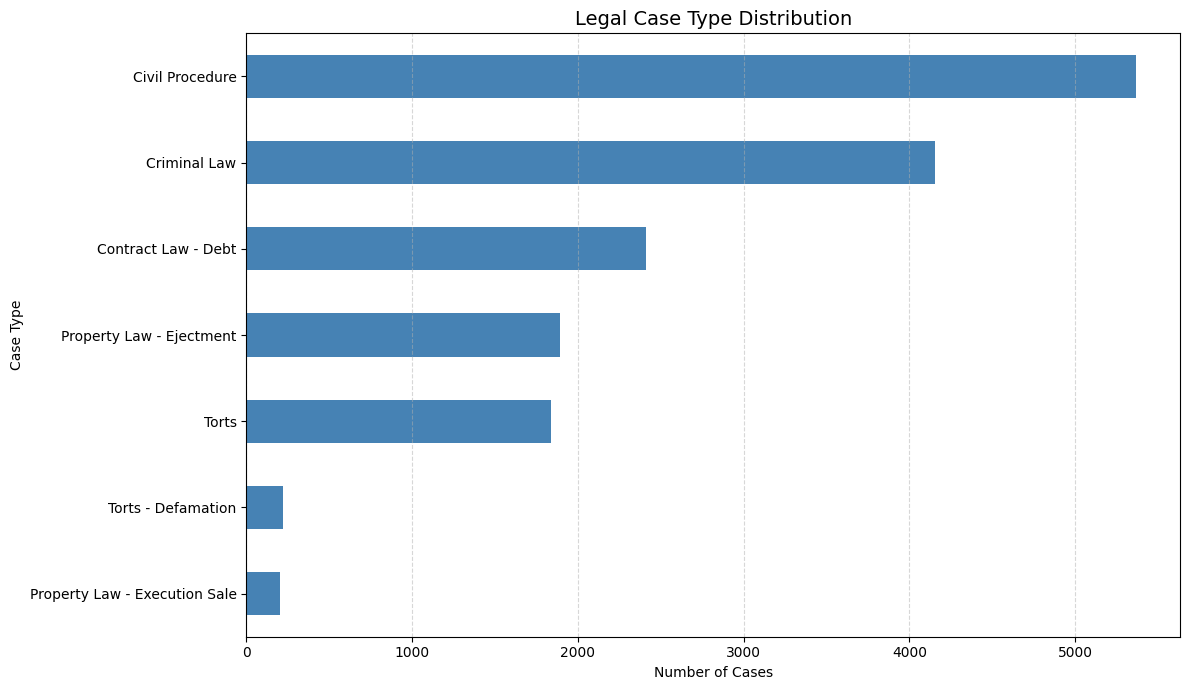

In [26]:
# ============================================================
# CASE TYPE VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

print("\nGenerating Case Type Visualization...")

# Get distribution
case_type_dist = df['Case_Type'].value_counts()

# Sort for better visualization
case_type_dist_sorted = case_type_dist.sort_values()

# Plot
plt.figure(figsize=(12, 7))

case_type_dist_sorted.plot(
    kind='barh',
    color='steelblue'
)

plt.title('Legal Case Type Distribution', fontsize=14)
plt.xlabel('Number of Cases')
plt.ylabel('Case Type')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# show
plt.show()

In [27]:
# ============================================================
# 4. CLEAN CASE TEXT (LEGAL NLP PREPROCESSING)
# ============================================================

def clean_legal_text(text):
    text = str(text).lower()
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = text.strip()
    return text

df['Case_Text'] = df['Case_Text'].apply(clean_legal_text)

In [28]:
# ============================================================
# 5. CASE TYPE MERGING
# ============================================================

case_type_mapping = {
    "Civil Procedure": "CIVIL",
    "Criminal Law": "CRIMINAL",
    "Contract Law - Debt": "CONTRACT",
    "Property Law - Ejectment": "PROPERTY",
    "Property Law - Execution Sale": "PROPERTY",
    "Torts - Defamation": "TORTS",
    "Torts": "TORTS"
}

# Create merged labels
df["Merged_Case_Type"] = df["Case_Type"].map(case_type_mapping)

# Check distribution
print("=" * 60)
print("MERGED CLASS DISTRIBUTION")
print("=" * 60)

print(df["Merged_Case_Type"].value_counts())

print("\nPercentage Distribution:\n")
print(df["Merged_Case_Type"].value_counts(normalize=True) * 100)

MERGED CLASS DISTRIBUTION
Merged_Case_Type
CIVIL       5364
CRIMINAL    4153
CONTRACT    2412
PROPERTY    2100
TORTS       2062
Name: count, dtype: int64

Percentage Distribution:

Merged_Case_Type
CIVIL       33.335405
CRIMINAL    25.809459
CONTRACT    14.989746
PROPERTY    13.050774
TORTS       12.814617
Name: proportion, dtype: float64


In [29]:
# ============================================================
# 7. LABEL ENCODING
# ============================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Convert text labels into numeric labels
df["Label"] = label_encoder.fit_transform(df["Merged_Case_Type"])

# Show mapping
print("=" * 60)
print("LABEL ENCODING MAPPING")
print("=" * 60)

for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} --> {i}")

LABEL ENCODING MAPPING
CIVIL --> 0
CONTRACT --> 1
CRIMINAL --> 2
PROPERTY --> 3
TORTS --> 4


In [30]:
# ============================================================
# 8. FEATURE & TARGET SPLIT
# ============================================================

# Text feature
X_text = df["Case_Text"]

# Numeric feature
X_numeric = df[["Case_Text_Full_Length"]]

# Target
y = df["Label"]

print("=" * 60)
print("FEATURE & TARGET INFO")
print("=" * 60)

print("Text Samples:", len(X_text))
print("Numeric Shape:", X_numeric.shape)
print("Labels:", len(y))

FEATURE & TARGET INFO
Text Samples: 16091
Numeric Shape: (16091, 1)
Labels: 16091


In [31]:
# ============================================================
# 9. TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

(
    X_text_train,
    X_text_test,
    X_num_train,
    X_num_test,
    y_train,
    y_test
) = train_test_split(
    X_text,
    X_numeric,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN TEST SPLIT COMPLETE")
print("=" * 60)

print("X_text_train:", X_text_train.shape)
print("X_text_test :", X_text_test.shape)
print("X_num_train :", X_num_train.shape)
print("X_num_test  :", X_num_test.shape)

TRAIN TEST SPLIT COMPLETE
X_text_train: (12872,)
X_text_test : (3219,)
X_num_train : (12872, 1)
X_num_test  : (3219, 1)


In [32]:
# ============================================================
# 10. TF-IDF VECTORIZATION
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=30000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

# Fit and transform training text
X_train_tfidf = tfidf_vectorizer.fit_transform(X_text_train)

# Transform test text
X_test_tfidf = tfidf_vectorizer.transform(X_text_test)

print("=" * 60)
print("TF-IDF COMPLETE")
print("=" * 60)

print("Train Shape:", X_train_tfidf.shape)
print("Test Shape :", X_test_tfidf.shape)

TF-IDF COMPLETE
Train Shape: (12872, 30000)
Test Shape : (3219, 30000)


In [33]:
# ============================================================
# 11. SCALE NUMERIC FEATURES
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_num_train_scaled = scaler.fit_transform(X_num_train)

X_num_test_scaled = scaler.transform(X_num_test)

print("=" * 60)
print("NUMERIC FEATURE SCALING COMPLETE")
print("=" * 60)
print(X_num_train_scaled.shape)

NUMERIC FEATURE SCALING COMPLETE
(12872, 1)


In [34]:
# ============================================================
# 12. COMBINE FEATURES
# ============================================================

from scipy.sparse import hstack

# Combine sparse TF-IDF with numeric features
X_train_combined = hstack([
    X_train_tfidf,
    X_num_train_scaled
])

X_test_combined = hstack([
    X_test_tfidf,
    X_num_test_scaled
])

print("=" * 60)
print("COMBINED FEATURE SHAPES")
print("=" * 60)

print("Train:", X_train_combined.shape)
print("Test :", X_test_combined.shape)

COMBINED FEATURE SHAPES
Train: (12872, 30001)
Test : (3219, 30001)


In [35]:
# ============================================================
# 13. APPLY SMOTE
# ============================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42,
    k_neighbors=3
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_combined,
    y_train
)

print("=" * 60)
print("SMOTE COMPLETE")
print("=" * 60)

print("Before SMOTE:", X_train_combined.shape)
print("After SMOTE :", X_train_smote.shape)

print("\nClass Distribution After SMOTE:\n")

import pandas as pd
print(pd.Series(y_train_smote).value_counts())

SMOTE COMPLETE
Before SMOTE: (12872, 30001)
After SMOTE : (21455, 30001)

Class Distribution After SMOTE:

Label
2    4291
0    4291
4    4291
1    4291
3    4291
Name: count, dtype: int64


In [36]:
# ============================================================
# 11. LOGISTIC REGRESSION MODEL
# ============================================================

from sklearn.linear_model import LogisticRegression

# Create model
lr_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

# Train model
lr_model.fit(X_train_smote, y_train_smote)

print("=" * 60)
print("LOGISTIC REGRESSION TRAINING COMPLETE")
print("=" * 60) 
# ============================================================
# 12. LOGISTIC REGRESSION PREDICTION
# ============================================================

# Predict
lr_predictions = lr_model.predict(X_test_combined)

print(lr_predictions[:20])

print("=" * 60)
print("PREDICTION COMPLETE")
print("=" * 60)

LOGISTIC REGRESSION TRAINING COMPLETE
[0 4 4 2 0 0 2 2 3 3 0 0 2 4 0 1 2 2 2 0]
PREDICTION COMPLETE


In [37]:
# ============================================================
# 13. LOGISTIC REGRESSION EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)

print(f"Accuracy: {lr_accuracy:.4f}")

print("\nCLASSIFICATION REPORT\n")
print(
    classification_report(
        y_test,
        lr_predictions,
        target_names=label_encoder.classes_
    )
)

print("\nCONFUSION MATRIX\n")
print(confusion_matrix(y_test, lr_predictions))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.7549

CLASSIFICATION REPORT

              precision    recall  f1-score   support

       CIVIL       0.80      0.79      0.80      1073
    CONTRACT       0.65      0.70      0.68       483
    CRIMINAL       0.84      0.73      0.78       831
    PROPERTY       0.73      0.73      0.73       420
       TORTS       0.66      0.79      0.72       412

    accuracy                           0.75      3219
   macro avg       0.74      0.75      0.74      3219
weighted avg       0.76      0.75      0.76      3219


CONFUSION MATRIX

[[849  98  28  58  40]
 [ 64 340  27  41  11]
 [ 81  33 609  11  97]
 [ 32  39  23 305  21]
 [ 29  13  38   5 327]]


In [38]:
# ============================================================
# 14. LINEAR SVM WITH SMOTE
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# ------------------------------------------------------------
# Feature Scaling for Sparse Matrix
# ------------------------------------------------------------
scaler = StandardScaler(with_mean=False)

X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test_combined)

# ------------------------------------------------------------
# Linear SVM Model
# ------------------------------------------------------------
svm_model = LinearSVC(
    max_iter=50000,
    dual=False
)

# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------
svm_model.fit(
    X_train_smote_scaled,
    y_train_smote
)

print("=" * 60)
print("SVM TRAINING COMPLETE")
print("=" * 60)

SVM TRAINING COMPLETE


In [39]:
# ============================================================
# 15. MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predict
predictions = svm_model.predict(X_test_combined)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("=" * 60)
print("SVM + SMOTE RESULTS")
print("=" * 60)

print(f"Accuracy: {accuracy:.4f}")

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        y_test,
        predictions,
        target_names=label_encoder.classes_
    )
)

print("\nCONFUSION MATRIX\n")

print(confusion_matrix(y_test, predictions))

SVM + SMOTE RESULTS
Accuracy: 0.6639

CLASSIFICATION REPORT

              precision    recall  f1-score   support

       CIVIL       0.66      0.85      0.74      1073
    CONTRACT       0.59      0.35      0.43       483
    CRIMINAL       0.64      0.78      0.70       831
    PROPERTY       0.73      0.51      0.60       420
       TORTS       0.79      0.48      0.60       412

    accuracy                           0.66      3219
   macro avg       0.68      0.59      0.62      3219
weighted avg       0.67      0.66      0.65      3219


CONFUSION MATRIX

[[910  42  89  22  10]
 [169 167  95  48   4]
 [113  42 645   4  27]
 [ 94  22  77 216  11]
 [ 85  12 109   7 199]]


In [40]:
# ============================================================
# 16. MODEL COMPARISON
# ============================================================

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        accuracy
    ]
})

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(comparison_df)

MODEL COMPARISON
                 Model  Accuracy
0  Logistic Regression  0.754893
1           Linear SVM  0.663871
